In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit

In [16]:
def quick_plot(func,x = None,y = None,yerr = None,label = None , title = None , x_title = None , 
               y_title = None, p0 = None,log = '.'):
    """
    Uses Scipy curve_fit to automatically create comparison plot and residual plot.
    MUST define func() before using function!
    Can take inf amount of function arguments!
    Stores Scipy Perr and popt
    """

    popt, pcov = curve_fit(func,x,y,sigma = yerr, absolute_sigma = True, p0=p0)

    perr = np.sqrt(np.diag(pcov))
    
    y_fit = func(x,*popt)
    
    print(*popt)

    plt.errorbar (x, y,fmt = 'o',yerr = yerr,label = label )
    plt.plot(x,y_fit)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(title)
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.grid()
    plt.show()


    resid = y - y_fit

    plt.errorbar(x,resid,yerr = yerr, fmt = 'o',label = label)
    plt.axhline(y = 0, color = 'black', linestyle = '--')
    plt.grid()
    plt.legend()
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(title)
    plt.show()


Standard Error o' Voltage: 0.0032964627506869653
Open Circuit Voltage = 0.0683 ± 0.0028 V
Output Resistance = 4.287 ± 0.240 Ω


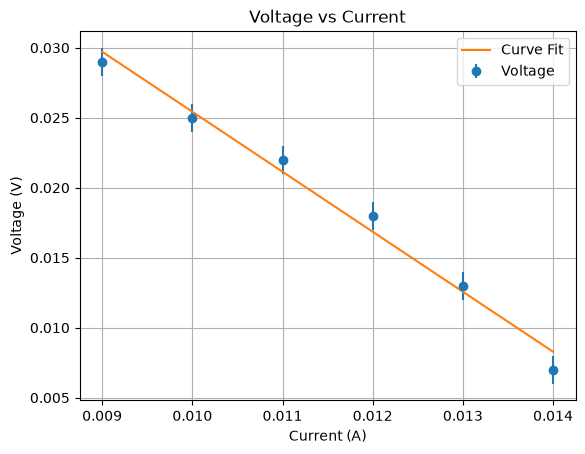

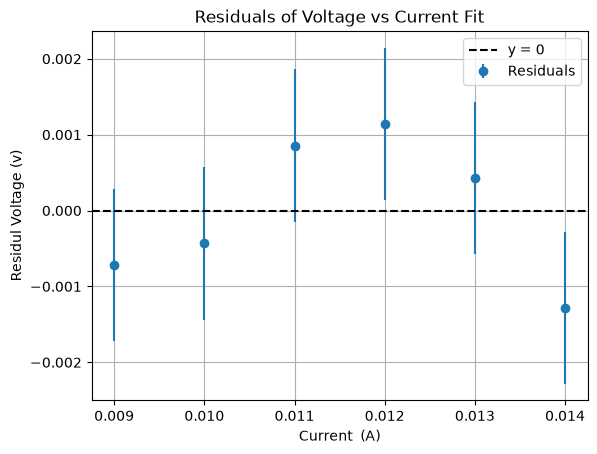

Reduced χ² = 1.14


In [32]:
#PRELIM EXPERIMENTE (LOAD RESISTOR)
#Uncertainty is incorrect, must go back and estimate uncertainty 
#of measurement with multimeter
I = np.array([0.014,0.013,0.012,0.011,0.010,0.009])
V = np.array([0.007,0.013,0.018,0.022,0.025,0.029])


standard_devs = np.std(V,ddof = 1)
standard_errorofV = stats.sem(V,axis=0)


accuracy = 0.4      # percent
counts = 1
resolution = 0.001  # V

sigma_v = np.sqrt(((accuracy / 100) * V)**2 + (counts * resolution)**2)

print(f"Standard Error o' Voltage: {standard_errorofV}")

def func(I,a,R):
    return -I * R + a 

popt, pcov = curve_fit(func,I,V,sigma = sigma_v, absolute_sigma = True)

perr = np.sqrt(np.diag(pcov))

#print(perr)

a = popt[0]
R = popt[1]

print(f"Open Circuit Voltage = {a:.4f} ± {perr[0]:.4f} V")
print(f"Output Resistance = {R:.3f} ± {perr[1]:.3f} Ω")

plt.errorbar (I, V,fmt = 'o',yerr = sigma_v,label = 'Voltage' )
plt.plot(I,a - I*R,label = 'Curve Fit')
plt.legend()
plt.title('Voltage vs Current')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (V)')
plt.grid()
plt.show()

resid = V - func(I,a,R)

plt.errorbar(I,resid,yerr = sigma_v, fmt = 'o',label = "Residuals")
plt.axhline(y = 0, color = 'black', linestyle = '--',label = 'y = 0')
plt.grid()
plt.legend()
plt.xlabel("Current  (A)")
plt.ylabel('Residul Voltage (v)')
plt.title("Residuals of Voltage vs Current Fit")
plt.show()

chi2 = np.sum((resid/sigma_v)**2)
dof = len(V) - len(popt)
reduced_chi2 = chi2/dof

print(f"Reduced χ² = {reduced_chi2:.2f}")

R = 1232.8812603310114


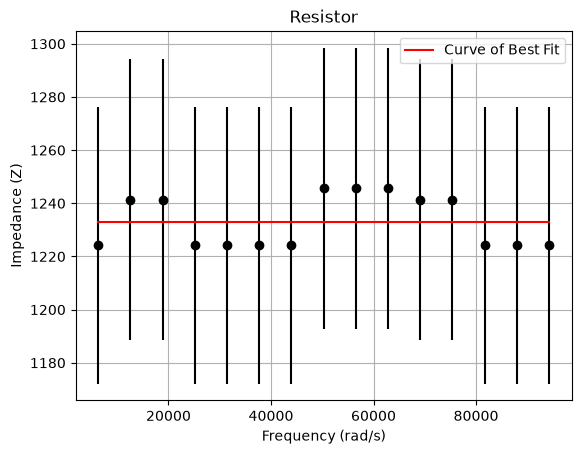

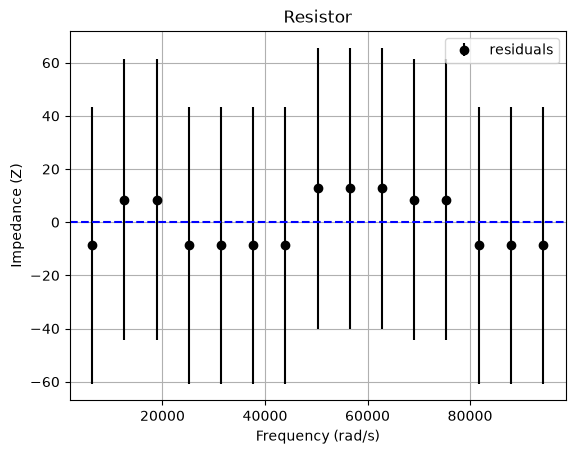

Reduced χ² = 0.04


In [34]:
#Resistor 
import pandas as pd
import numpy as np

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - Resistor.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

f = df.iloc[::,0] *np.pi *2 
phase = df.iloc[::,3]

R_sense = 1000

Vr = df.iloc[:,1]
Vs = df.iloc[:,2]

z = (df.iloc[:,1]/ df.iloc[:,2]) * R_sense

rel_sigma_Vr = (0.03*Vr + 0.001)/Vr
rel_sigma_Vs = (0.03*Vs + 0.001)/Vs

sigma_z = abs(z) * np.sqrt( (rel_sigma_Vr)**2 + (rel_sigma_Vs)**2 + (0.0003)**2 )




def func(f,R):
    return  R *np.ones_like(f)

popt, pcov = curve_fit(func,f,z,sigma = sigma_z, absolute_sigma = True)

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)
    
print(f"R = {popt[0]}")


plt.errorbar (f, z,fmt = 'o',yerr = sigma_z,color = 'black')
plt.plot(f,y_fit,label = f"Curve of Best Fit",color = 'red')
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Impedance (Z)")
plt.title("Resistor")
plt.legend()
plt.grid()
plt.show()


resid = z - y_fit

plt.errorbar(f,resid,yerr = sigma_z, fmt = 'o',label = 'residuals',color = 'black')
plt.axhline(y = 0,  linestyle = '--',color = 'blue')
plt.grid()
plt.legend()
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Impedance (Z)")
plt.title("Resistor")
plt.show()

chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)
reduced_chi2 = chi2/dof

print(f"Reduced χ² = {reduced_chi2:.2f}")

Fitted Inductance (L): 0.016920463558556455 ± 0.00018643096142087674


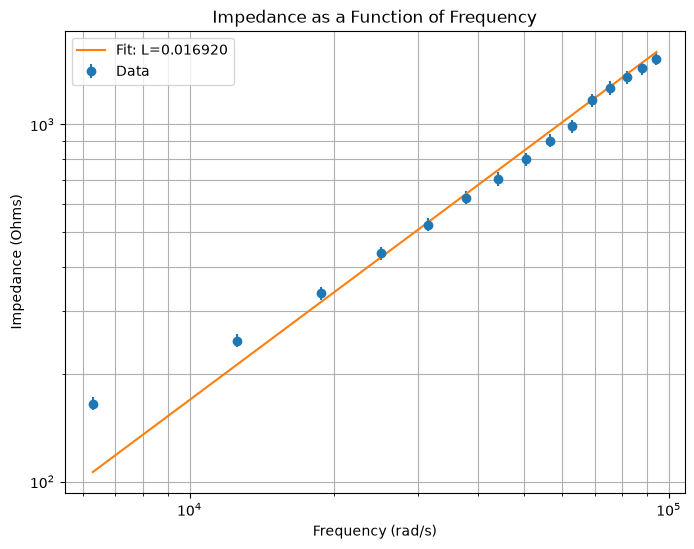

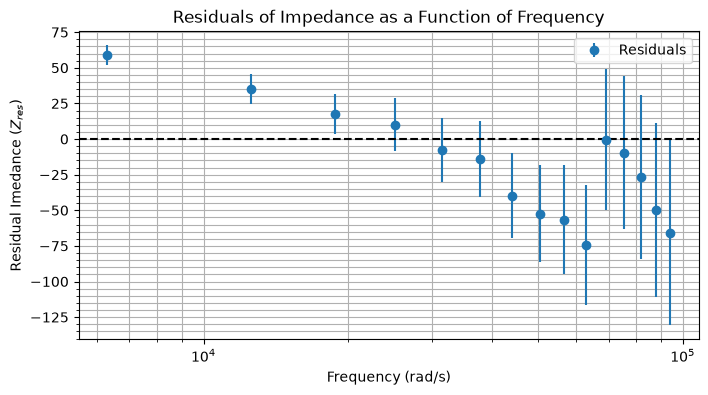

10.301205035471108
<class 'numpy.float64'>
Reduced χ² = 6.82


In [33]:
# Given data arrays
#uncertainty is incorrect, must find uncertainty of osc
#for example, we can assume a one percent error in all measurements
#due to flucuations in voltages during readings
f = (2*np.pi) * 1000 *np.linspace(1,15,15)
R_sense = 1000.3
v_1_200 = np.array([7.6,
                    11.2,
                    14.8,
                    18.8,
                    22,
                    25.2,
                    27.6,
                    30,
                    32.4,
                    34.4,
                    38.8,
                    40,
                    41.2,
                    42,
                    42.8])

v_2_200 = np.array([46,
                    45.2,
                    44,
                    43.2,
                    42,
                    40.4,
                    39.2,
                    37.6,
                    36,
                    34.8,
                    33.2,
                    31.6,
                    30.4,
                    29.2,
                    28])

phase = np.array([43.2,
                    59,
                    69.4,
                    76.1,
                    78.6,
                    80.5,
                    81.8,
                    84,
                    84,
                    84.5,
                    76.8,
                    78.1,
                    79.6,
                    80.1,
                    80.8])

# Calculate impedance
z = (v_1_200 / v_2_200) * R_sense 

#propagate errors assuming one percent error in osc measurments
# and 0.03 percent error in load resistance: 
sigma_z = z * np.sqrt( (0.03)**2 + (0.03)**2 + (0.0003)**2 )


def func(f, L):
    return f * L  

# Perform the curve fit
popt, pcov = curve_fit(func, f, z, sigma=sigma_z, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))
L = popt[0]
sigma_L = perr[0]

print("Fitted Inductance (L):", L, "±", perr[0])

# Plotting the impedance and fit
plt.figure(figsize=(8, 6))
plt.errorbar(f, z, yerr=sigma_z, fmt='o', label='Data')

# Generate smooth points to plot the fit
plt.plot(f, func(f, L), '-', label=f'Fit: L={L:.6f}')

plt.xlabel("Frequency (rad/s)")
plt.ylabel("Impedance (Ohms)")
plt.xscale('log')
plt.yscale('log')
plt.minorticks_on()
plt.grid(True,which='both')
plt.title("Impedance as a Function of Frequency")
plt.legend()
plt.show()

# Calculate and plot residuals
resid = z - func(f, L)
plt.figure(figsize=(8, 4))
plt.errorbar(f, resid, yerr=sigma_z, fmt='o', label="Residuals")
plt.axhline(y=0, color='black', linestyle='--')
plt.minorticks_on()
plt.grid(True,which='both')
plt.xscale('log')
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Residual Imedance ($Z_{res}$)")
plt.title("Residuals of Impedance as a Function of Frequency")
plt.legend()
plt.show()

z_score = (L - 0.015)/sigma_L
print(z_score)

print(type(popt[0]))

chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)
reduced_chi2 = chi2/dof

print(f"Reduced χ² = {reduced_chi2:.2f}")




1.4870512813848959e-08


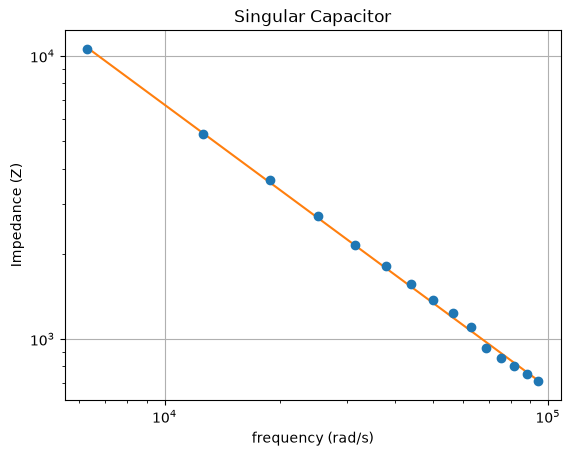

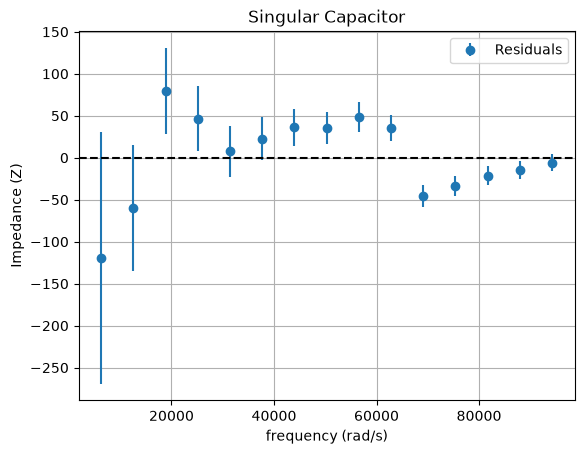

Reduced χ² = 8.25


In [17]:
#Capacitor
import pandas as pd

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - Capacitor.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

R_sense = 1000

z = (df.iloc[::,1]/ df.iloc[::,2]) * R_sense

#propagate errors assuming one percent error in osc measurments
# and 0.03 percent error in load resistance: 
sigma_z = abs(z) * np.sqrt( (0.01)**2 + (0.01)**2 + (0.0003)**2 )

f = df.iloc[::,0] *2*np.pi

def func(f,c):
    return 1/(f*c)

quick_plot(func,x = f, y = z, yerr = sigma_z, title = 'Singular Capacitor'
           , x_title = 'frequency (rad/s)', y_title = 'Impedance (Z)', label = 'Residuals')

chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)
reduced_chi2 = chi2/dof

print(f"Reduced χ² = {reduced_chi2:.2f}")

-6066.7814845954335 1.318340949719512e-08 0.017923256885799085


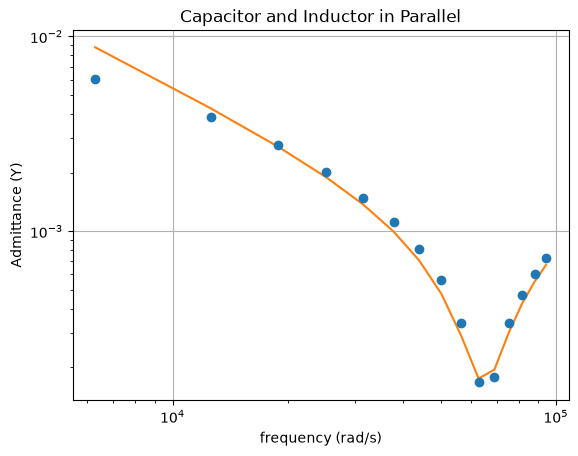

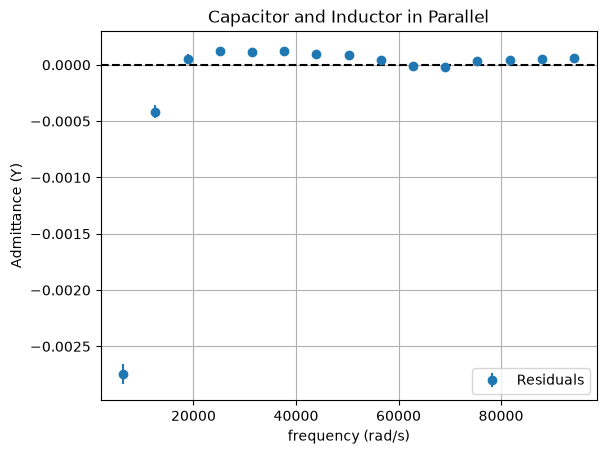

Reduced χ² = 8.25


In [18]:
#inductor and capacitor in parallel

import pandas as pd

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - inductor_and_capacitor_in_parallel.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

R_sense = 1000

z = (df.iloc[::,1]/ df.iloc[::,2]) * R_sense
y = 1/z

#propagate errors assuming one percent error in osc measurments
# and 0.03 percent error in load resistance: 
sigma_y = abs(y) * np.sqrt( (0.01)**2 + (0.01)**2 + (0.0003)**2 )



f = df.iloc[::,0] *2*np.pi

def func(f,R_int,C,L):
    return np.sqrt(((1/R_int)**2)+((f*C) - (1/(f*L)))**2)


quick_plot(func,x = f, y = y, yerr = sigma_y, title = 'Capacitor and Inductor in Parallel'
           , x_title = 'frequency (rad/s)', y_title = 'Admittance (Y)', label = 'Residuals',log = 'log',p0=[2000, 1e-7, 0.1])

chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)
reduced_chi2 = chi2/dof

print(f"Reduced χ² = {reduced_chi2:.2f}")



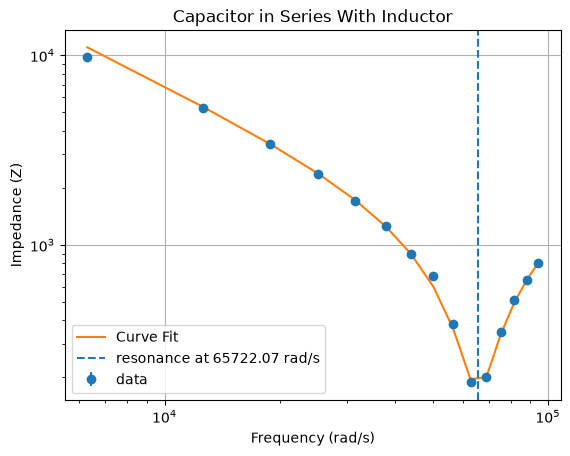

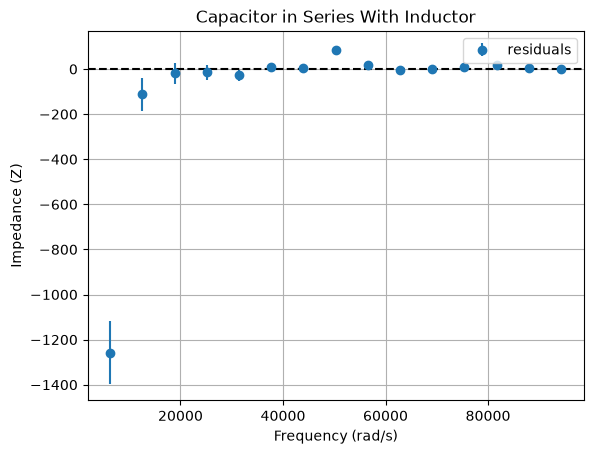

Reduced χ² (impedance) = 16.00


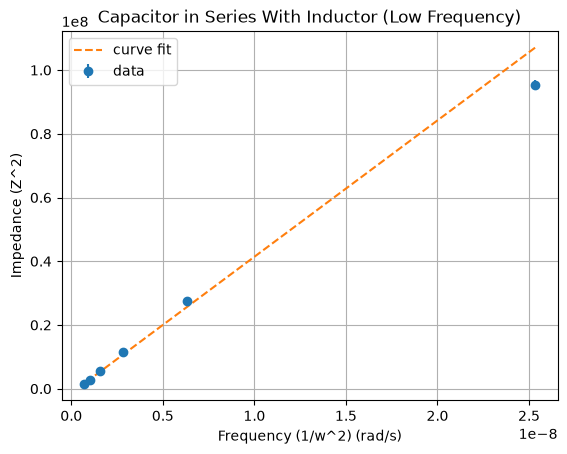

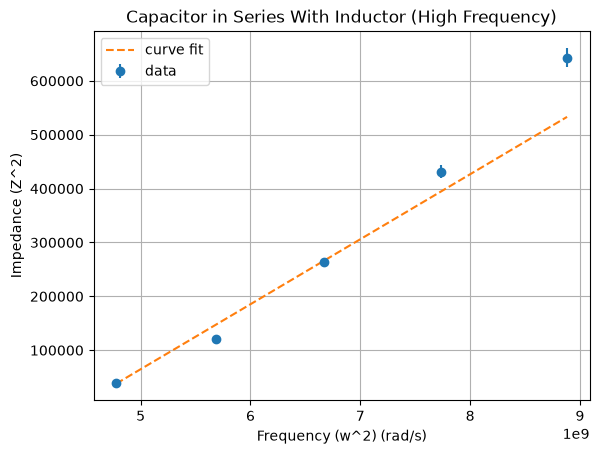

Resonance at 67642.31 rad/s


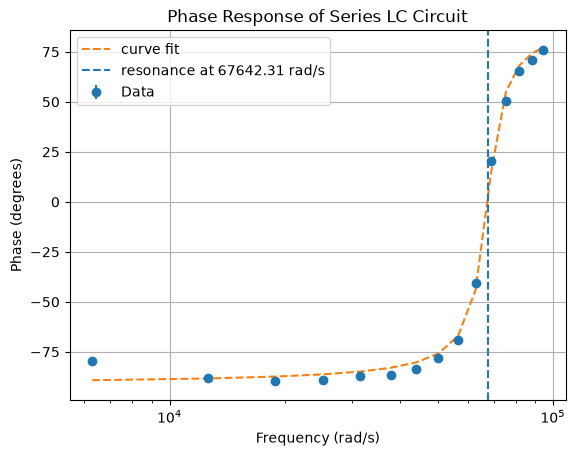

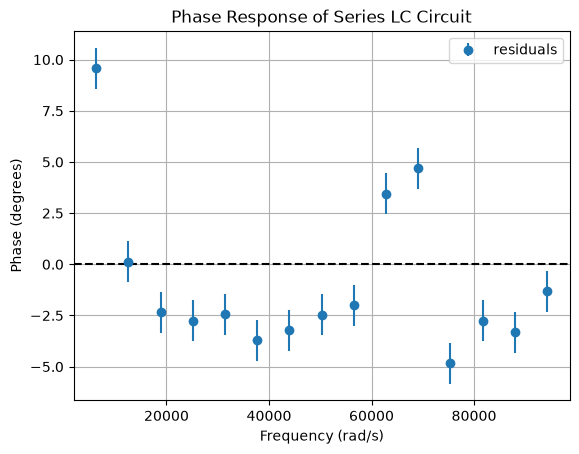

Reduced χ² (impedance) = 18.56


In [ ]:
#Inductor and Capacitor In Series

import pandas as pd

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - inductor_and_capacitor_in_series.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

phase = df.iloc[:,3]

f = df.iloc[::,0] *np.pi *2 

R_sense = 1000

z = (df.iloc[::,1]/ df.iloc[::,2]) * R_sense

sigma_z = abs(z) * np.sqrt( (0.01)**2 + (0.01)**2 + (0.0003)**2 )


def func(f,L,C,R):
    return np.sqrt(R**2 + (f*L - 1/(f*C))**2)

popt, pcov = curve_fit(func,f,z,sigma = sigma_z, absolute_sigma = True,p0=[2000, 1e-7, 0.1])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)


L = popt[0]
C = popt[1]
res = 1/np.sqrt(L*C)


plt.errorbar (f, z,fmt = 'o',yerr = sigma_z,label = 'data')
plt.plot(f,y_fit,label = f"Curve Fit")
plt.axvline(res,linestyle = '--', label = f"resonance at {res:.2f} rad/s")
plt.legend()
plt.xlabel("Frequency (rad/s)")
plt.xscale('log')
plt.yscale('log')
plt.ylabel("Impedance (Z)")
plt.title("Capacitor in Series With Inductor")
plt.grid()
plt.show()


resid = z - y_fit

plt.errorbar(f,resid,yerr = sigma_z, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Impedance (Z)")
plt.title("Capacitor in Series With Inductor")
plt.show()

chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)
reduced_chi2 = chi2/dof

print(f"Reduced χ² (impedance) = {reduced_chi2:.2f}")


#Low Frequency

C = None

lowf = list(1/f**2)[:6]
z_sqr = list(z**2)[:6]

lowf = np.array(lowf)
z_sqr = np.array(z_sqr)

sigma_zsqr = z_sqr * np.sqrt( (0.01)**2 + (0.01)**2 + (0.0003)**2 )

sigma_zsqr = np.array(list(sigma_zsqr)[:6])

def func(lowf,m,b):
    return m*lowf + b

popt, pcov = curve_fit(func,lowf,z_sqr,sigma = sigma_zsqr, absolute_sigma = True,p0 =[1e14,100])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(lowf,*popt)

plt.errorbar(lowf,z_sqr,yerr = sigma_zsqr,fmt = 'o',label  = 'data')
plt.plot(lowf,y_fit,linestyle = '--',label = 'curve fit')
plt.grid()
plt.legend()
plt.xlabel("Frequency (1/w^2) (rad/s)")
plt.ylabel("Impedance (Z^2)")
plt.title("Capacitor in Series With Inductor (Low Frequency)")
plt.show()


#High Frequency

C = None
lowf = None 
z_sqr = None 
sigma_zsqr = None

highf = list(f**2)[10:15]
z_sqr = list(z**2)[10:15]

highf = np.array(highf)
z_sqr = np.array(z_sqr)

sigma_zsqr = 2*z[10:15]*sigma_z[10:15]

sigma_zsqr = np.array(list(sigma_zsqr))

def func(highf,d,c):
    return d*highf + c

popt, pcov = curve_fit(func,highf,z_sqr,sigma = sigma_zsqr, absolute_sigma = True,p0 =[1e14,100])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(highf,*popt)

plt.errorbar(highf,z_sqr,yerr = sigma_zsqr,fmt = 'o',label = 'data')
plt.plot(highf,y_fit,linestyle = '--',label = 'curve fit')
plt.grid()
plt.legend()
plt.xlabel("Frequency (w^2) (rad/s)")
plt.ylabel("Impedance (Z^2)")
plt.title("Capacitor in Series With Inductor (High Frequency)")
plt.show()






#_______________PHASE__________________________________________________________________________



sigma_phase = np.ones_like(phase) * 1 # degrees

def func(f,L,C,R_int):
    return np.degrees(np.arctan(((f*L)-(1/(f*C)))/R_int))


popt, pcov = curve_fit(func,f,phase,sigma = sigma_phase, absolute_sigma = True, p0=[0.01,1e-7,10],
    bounds=(0,np.inf),
    maxfev=10000
)

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)

L = popt[0]
C = popt[1]
res = 1/np.sqrt(L*C)

print(f"Resonance at {res:.2f} rad/s")

plt.errorbar(f, phase, yerr=sigma_phase, fmt='o',label = 'Data')
plt.plot(f,y_fit,label = 'curve fit',linestyle = '--')
plt.axvline(res,linestyle = '--',label = f'resonance at {res:.2f} rad/s')
plt.legend()
plt.grid()
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Phase (degrees)")
plt.title("Phase Response of Series LC Circuit")
plt.xscale('log')
plt.show()


resid = phase - y_fit

plt.errorbar(f,resid,yerr = sigma_phase, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Phase (degrees)")
plt.title("Phase Response of Series LC Circuit")
plt.show()

chi2 = np.sum((resid/sigma_phase)**2)
dof = len(phase) - len(popt)
reduced_chi2 = chi2/dof

print(f"Reduced χ² (impedance) = {reduced_chi2:.2f}")


L = 16.37
R_int = 1346.62


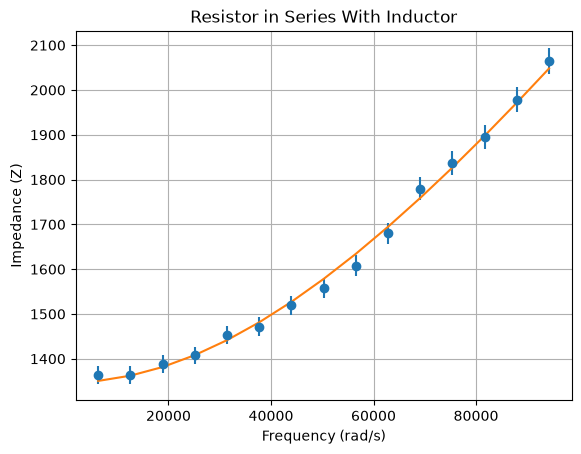

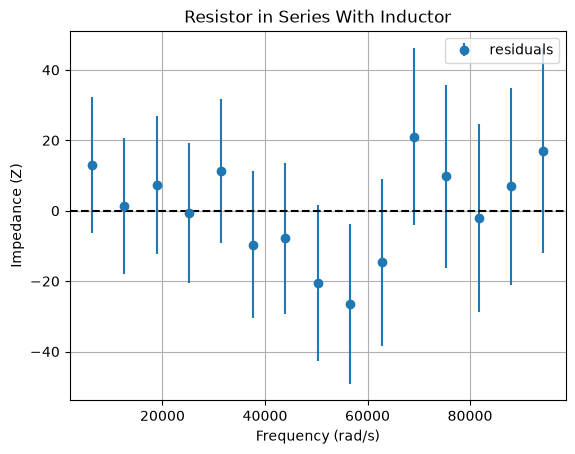

Reduced χ² = 0.39
Inductance: 119.95mH
Total Resistance: 10560.09ohms


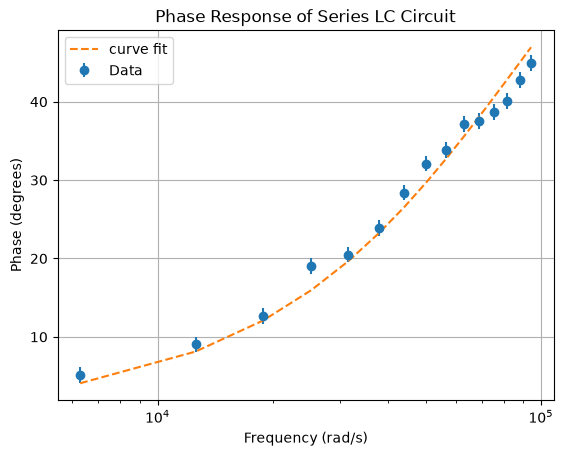

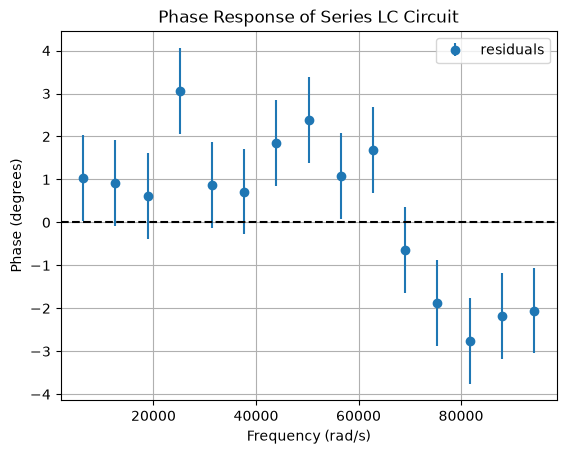

Reduced χ² (phase) = 3.58


In [115]:
#Inductor and Resistor In Series 

import pandas as pd
import numpy as np

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - inductor_and_resistor_in_series.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

f = df.iloc[::,0] *np.pi *2 

R_sense = 1000

z = (df.iloc[::,1]/ df.iloc[::,2]) * R_sense

sigma_z = abs(z) * np.sqrt( (0.01)**2 + (0.01)**2 + (0.0003)**2 )


def func(f,L,R_tot):
    return np.sqrt(((f*L)**2) + (R_tot)**2)

popt, pcov = curve_fit(func,f,z,sigma = sigma_z, absolute_sigma = True)

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)
    
print(f"L = {popt[0]*1000:.2f}")
print(f"R_int = {popt[1]:.2f}")

plt.errorbar (f, z,fmt = 'o',yerr = sigma_z)
plt.plot(f,y_fit,label = f"{func}")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Impedance (Z)")
plt.title("Resistor in Series With Inductor")
plt.grid()
plt.show()


resid = z - y_fit

plt.errorbar(f,resid,yerr = sigma_z, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Impedance (Z)")
plt.title("Resistor in Series With Inductor")
plt.show()

chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)
reduced_chi2 = chi2/dof

print(f"Reduced χ² = {reduced_chi2:.2f}")









#_______________PHASE__________________________________________________________________________

phase  = df.iloc[:,3]

sigma_phase = np.ones_like(phase) * 1 # degrees

L = None
R = None

def func(f,L,R):
    return np.degrees(np.arctan((f*L)/R))


popt, pcov = curve_fit(func,f,phase,sigma = sigma_phase, absolute_sigma = True,p0=[0.1, 10])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)

L = popt[0]
R = popt[1]

print(f"Inductance: {L*1000:.2f}mH")
print(f"Total Resistance: {R:.2f}ohms")


plt.errorbar(f, phase, yerr=sigma_phase, fmt='o',label = 'Data')
plt.plot(f,y_fit,label = 'curve fit',linestyle = '--')
plt.legend()
plt.grid()
plt.xscale('log')
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Phase (degrees)")
plt.title("Phase Response of Series LC Circuit")
plt.show()


resid = phase - y_fit

plt.errorbar(f,resid,yerr = sigma_phase, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Phase (degrees)")
plt.title("Phase Response of Series LC Circuit")
plt.show()

chi2 = np.sum((resid/sigma_phase)**2)
dof = len(phase) - len(popt)
reduced_chi2 = chi2/dof

print(f"Reduced χ² (phase) = {reduced_chi2:.2f}")




R_int = 1195.3832748655693
C = 14.546353908503477 nF


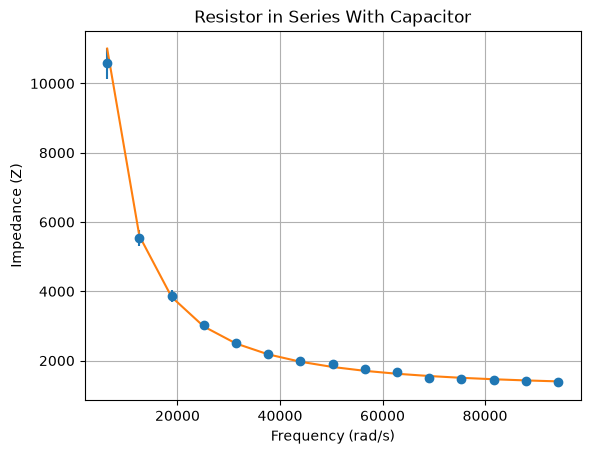

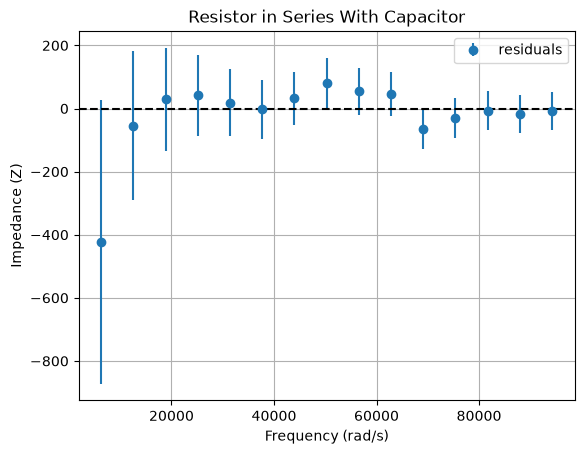

Reduced χ² = 0.35


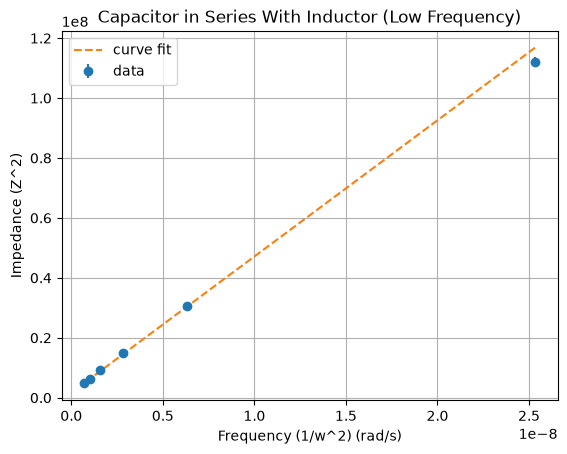

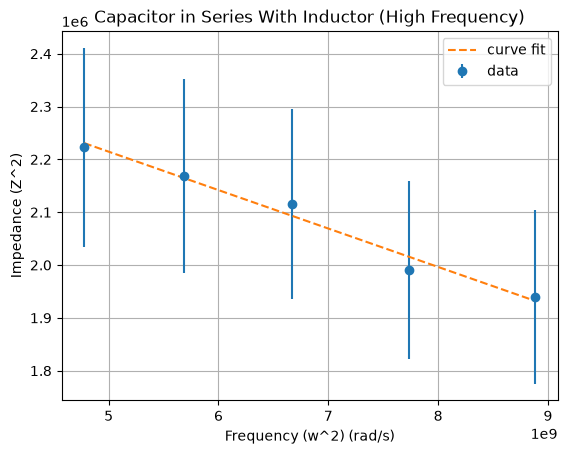

Total Resistance: 0.440 kΩ
Capacitance: 42.80 nF


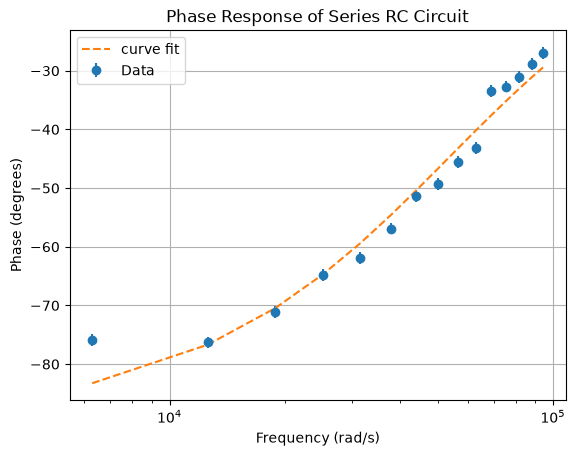

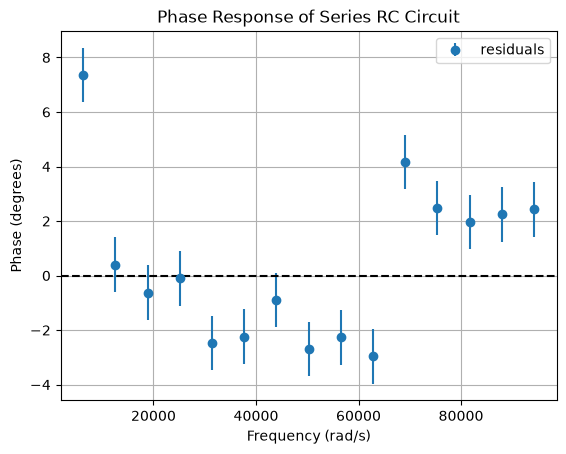

Reduced χ² (phase) = 9.71


In [124]:
#Capacitor and Resistor In Series 
import pandas as pd
import numpy as np

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - capcitor_and_resistor_in_series.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

f = df.iloc[::,0] *np.pi *2 
phase = df.iloc[::,3]

R_sense = 1000

z = (df.iloc[::,1]/ df.iloc[::,2]) * R_sense

sigma_z = abs(z) * np.sqrt( (0.03)**2 + (0.03)**2 + (0.0003)**2 )




def func(f,R,C):
    return  np.sqrt((R)**2 + ((1/(f*C))**2))

popt, pcov = curve_fit(func,f,z,sigma = sigma_z, absolute_sigma = True,p0=[195,14.78e-8])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)
    
print(f"R_int = {popt[0]}")
print(f"C = {np.abs(popt[1])*1e9} nF")

plt.errorbar (f, z,fmt = 'o',yerr = sigma_z)
plt.plot(f,y_fit,label = f"{func}")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Impedance (Z)")
plt.title("Resistor in Series With Capacitor")
plt.grid()
plt.show()


resid = z - y_fit

plt.errorbar(f,resid,yerr = sigma_z, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Impedance (Z)")
plt.title("Resistor in Series With Capacitor")
plt.show()

chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)
reduced_chi2 = chi2/dof

print(f"Reduced χ² = {reduced_chi2:.2f}")









#Low Frequency___________________________________________________

C = None

lowf = list(1/f**2)[:6]
z_sqr = list(z**2)[:6]

lowf = np.array(lowf)
z_sqr = np.array(z_sqr)

sigma_zsqr = z_sqr * np.sqrt( (0.01)**2 + (0.01)**2 + (0.0003)**2 )

sigma_zsqr = np.array(list(sigma_zsqr)[:6])

def func(lowf,m,b):
    return m*lowf + b

popt, pcov = curve_fit(func,lowf,z_sqr,sigma = sigma_zsqr, absolute_sigma = True,p0 =[1e14,100])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(lowf,*popt)

plt.errorbar(lowf,z_sqr,yerr = sigma_zsqr,fmt = 'o',label  = 'data')
plt.plot(lowf,y_fit,linestyle = '--',label = 'curve fit')
plt.grid()
plt.legend()
plt.xlabel("Frequency (1/w^2) (rad/s)")
plt.ylabel("Impedance (Z^2)")
plt.title("Capacitor in Series With Inductor (Low Frequency)")
plt.show()












#High Frequency___________________________________________

C = None
lowf = None 
z_sqr = None 
sigma_zsqr = None

highf = list(f**2)[10:15]
z_sqr = list(z**2)[10:15]

highf = np.array(highf)
z_sqr = np.array(z_sqr)

sigma_zsqr = 2*z[10:15]*sigma_z[10:15]

sigma_zsqr = np.array(list(sigma_zsqr))

def func(highf,d,c):
    return d*highf + c

popt, pcov = curve_fit(func,highf,z_sqr,sigma = sigma_zsqr, absolute_sigma = True,p0 =[1e14,100])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(highf,*popt)

plt.errorbar(highf,z_sqr,yerr = sigma_zsqr,fmt = 'o',label = 'data')
plt.plot(highf,y_fit,linestyle = '--',label = 'curve fit')
plt.grid()
plt.legend()
plt.xlabel("Frequency (w^2) (rad/s)")
plt.ylabel("Impedance (Z^2)")
plt.title("Capacitor in Series With Inductor (High Frequency)")
plt.show()














#Phase___________________________________________________________





phase  = df.iloc[:,3]

sigma_phase = np.ones_like(phase) * 1 # degrees

C = None
R = None

def func(f,R,C):
    return -np.degrees(np.arctan(1/(f*R*C)))


popt, pcov = curve_fit(func,f,phase,sigma = sigma_phase, absolute_sigma = True,p0=[1000,1e-7],
    bounds=(0,np.inf))

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)

R = popt[0]
C = popt[1]

print(f"Total Resistance: {R/1000:.3f} kΩ")
print(f"Capacitance: {C*1e9:.2f} nF")


plt.errorbar(f, phase, yerr=sigma_phase, fmt='o',label = 'Data')
plt.plot(f,y_fit,label = 'curve fit',linestyle = '--')
plt.legend()
plt.grid()
plt.xscale('log')
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Phase (degrees)")
plt.title("Phase Response of Series RC Circuit")
plt.show()


resid = phase - y_fit

plt.errorbar(f,resid,yerr = sigma_phase, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Phase (degrees)")
plt.title("Phase Response of Series RC Circuit")
plt.show()

chi2 = np.sum((resid/sigma_phase)**2)
dof = len(phase) - len(popt)
reduced_chi2 = chi2/dof

print(f"Reduced χ² (phase) = {reduced_chi2:.2f}")